# [LAB-10] 로지스틱회귀ㅣ02-1-로지스틱 회귀의 의미(실습코드).ipynb

## #01. 준비작업 

In [ ]:
# 순서 정리 (실습코드 기준: 회귀계수 해석 → 오즈 → 로짓 → 오즈비 → 보고 모듈화)

# 1. 준비작업 + 전처리

# 라이브러리, 데이터 불러오기
# 라벨링 필요 여부 판단 — Species처럼 문자열이면 라벨링 필요, Outcome처럼 이미 0/1 숫자면 라벨링 스킵 (이 판단 자체가 새로 추가된 단계)

# 2. 모형 적합

# my_logit.fit_model → 회귀계수(B), 절편 확인

# 3. "B를 선형회귀처럼 읽으면 왜 틀리는지" 증명

# x를 1씩 늘려가며 예측확률의 증가폭을 직접 비교 → 구간마다 증가폭이 다름을 확인 (S자 곡선이라 기울기가 일정하지 않음)

# 4. 오즈(odds) 도입

# 확률-오즈 대응표 확인
# 같은 x 증가폭에서 오즈가 일정한 배율로 증가하는지 확인 (확률은 불규칙, 오즈는 규칙적 배율)

# 5. 로짓(logit) 도입

# 확률/오즈/로짓 세 가지를 나란히 시각화 → 로짓만 완전한 직선으로 나옴
# → 결론: "B는 로짓의 변화량"이라는 게 여기서 증명됨

# 6. 오즈비(OR) 계산

# exp(B) = 오즈비

# 7. 결과 보고 모듈화 (02-2)

# report_fitness (모형 적합도) → report_variables (오즈비 표) → report_variables_text (해석 문장 자동생성) → plot_odds (시각화)

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
import numpy as np
from IPython.display import Markdown, display

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 및 전처리
1단원과 동일한 데이터 사용  

In [2]:
origin = load_data('iris_bin')

# 종속변수 라벨링 (versicolor =0, virginica = 1)
df = my_prep.labeling(origin, columns=['Species'])

df.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)

Species (1종) : versicolor=0
Species (2종) : versicolor=0, virginica=1


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,0
1,6.400,3.200,4.500,1.500,0
2,6.900,3.100,4.900,1.500,0
3,5.500,2.300,4.000,1.300,0
4,6.500,2.800,4.600,1.500,0


## #02. 회귀계수를 그대로 해석할 수 없는 이유 

### 1. 단순로지스틱 회귀 모형 접합 
1단원에서 만든, 꽃받침 길이 하나로 적합한 단순로지스틱 회귀 모형을 다시 적합한다. 

In [3]:
data1 = df[['Sepal_Length', 'Species']]

fit1 = my_logit.fit_model(data1, y='Species', summary=True)

print(f"회귀계수(B) : {fit1.params['Sepal_Length']:.4f}")
print(f"절편 : {fit1.params['const']:.4f}")

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        17:30:08   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925
회귀계수(B) : 2.0129
절편 : -12.5708


### 2. "B=2.0129"는 무슨 뜻인가? 
선형회귀라면 "x가 1증가할때 y가 2.0129증가"로 읽으면 되지만,\
로지스틱 회귀에서 "꽃받침 길이가 1cm늘면 확률이 2.0129 증가"라고 읽으면 틀린다.
확률은 0~1사이의 값이므로 2.0129만큼 증가할 수 없다\
실제로 확률의 증가폭은 x의 위치마다 다르다.(S자 곡선의 기울기가 구간마다 다르기 때문)

In [4]:
# 꽃받침 길이를 1cm씩 늘려가며 예측 확률의 '증가폭'을 비교 
lengths = [5.0, 6.0, 7.0, 8.0]  

# 예측값 생성 
probs = my_logit.predict(fit1, DataFrame({'Sepal_Length':lengths}))['proba']

check = DataFrame({'Sepal_Length': lengths, '확률(P)':probs.values})
check['확률 증가폭'] = check['확률(P)'].diff() # 직전 값 대비 확률의 증가량 

check 

,Sepal_Length,확률(P),확률 증가폭
0,5.000,0.075,NaN
1,6.000,0.379,0.304
2,7.000,0.820,0.441
3,8.000,0.972,0.151


## #03. 오즈(odds)

### 1. 오즈의 정의 

In [5]:
# 확률과 오즈의 대응 관계 
p = np.array([0.1, 0.2, 0.5, 0.8, 0.9, 0.99])

odds_table = DataFrame({
    '확률(P)': p, 
    '오즈(P/(1-P))': p/(1-p)    
})

odds_table

,확률(P),오즈(P/(1-P))
0,0.100,0.111
1,0.200,0.250
2,0.500,1.000
3,0.800,4.000
4,0.900,9.000
5,0.990,99.000


### 2. 오즈는 일정한 비율로 증가한다. 
앞에서 본 꽃받침 길이 5,6,7,8cm의 예측 확률을 오즈로 바궈서 다시 비교해 보자 

In [6]:
check['오즈'] = check['확률(P)']/ (1-check['확률(P)'])

# 직전 오즈 대비 몇 배가 되었는가 = 오즈의 '배율'
check['오즈 배율'] = check['오즈'] / check['오즈'].shift(1)

check

,Sepal_Length,확률(P),확률 증가폭,오즈,오즈 배율
0,5.000,0.075,NaN,0.082,NaN
1,6.000,0.379,0.304,0.611,7.485
2,7.000,0.820,0.441,4.571,7.485
3,8.000,0.972,0.151,34.214,7.485


## #04. 로짓(Logit)

### 1. 확률, 오즈, 로짓 비교 

In [7]:
# 확률/ 오즈/ 로짓을 각각 그렷 비교 (실제 Sepal_Length 값 사용)
# 실제 관측된 꽃받침 길이를 x축으로 사용 (선을 매끄럽게 잇기 위해 정렬)
x_real = data1['Sepal_Length'].sort_values().values

# my_logit.predict: 독립변수 데이터 프레임을 주면 예측 확률('proba')을 돌려준다
p_real_df = my_logit.predict(fit1, DataFrame({'Sepal_Length':x_real}))
p_real = p_real_df['proba'].values

odds_real = p_real/ (1-p_real) # 오즈 
logit_real = np.log(odds_real) # 로짓 = log(오즈)   

print(f"확률(P) : {p_real[:5]} ... {p_real[-5:]}")
print(f"오즈 : {odds_real[:5]} ... {odds_real[-5:]}")
print(f"로짓 : {logit_real[:5]} ... {logit_real[-5:]}")

확률(P) : [0.0625357  0.0625357  0.07542828 0.07542828 0.09072162] ... [0.94924971 0.94924971 0.94924971 0.94924971 0.96548845]
오즈 : [0.06670729 0.06670729 0.08158186 0.08158186 0.0997732 ] ... [18.70432083 18.70432083 18.70432083 18.70432083 27.97580299]
로짓 : [-2.70744104 -2.70744104 -2.50614834 -2.50614834 -2.30485564] ... [2.92875456 2.92875456 2.92875456 2.92875456 3.33133996]


### 2. 확률, 오즈, 로짓 비교 결과 시각화 

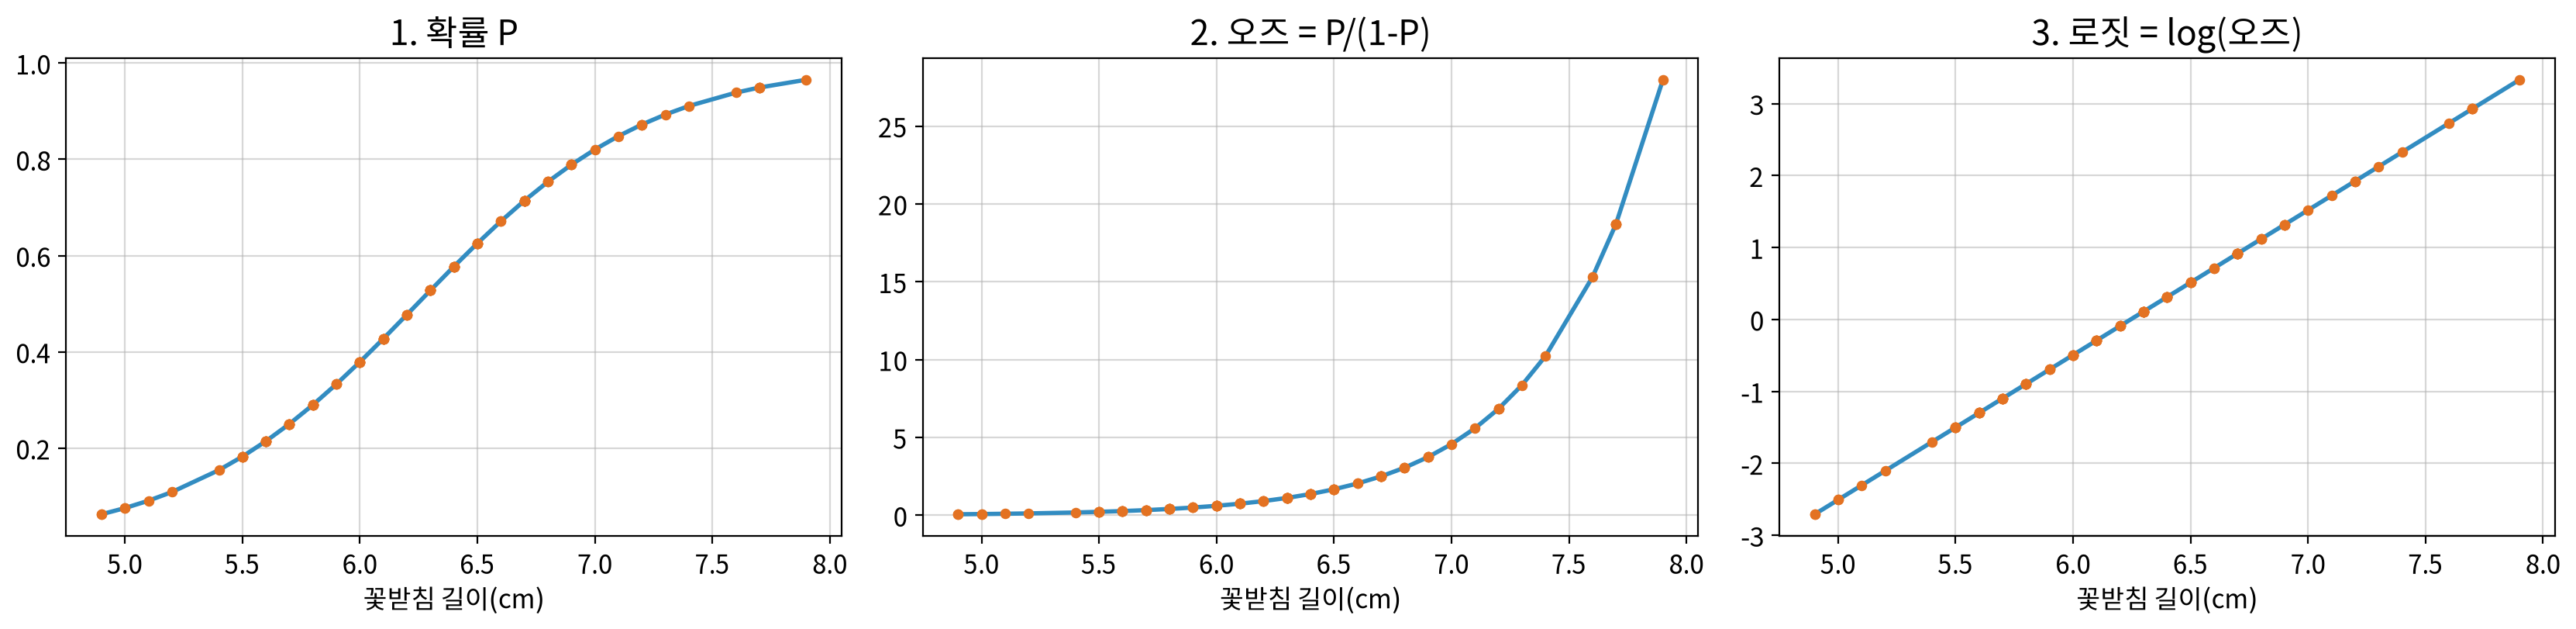

In [8]:
fig, ax = my_plot.init(rows=1, cols=3, width=560, height=440)

# 파란 선 = 모델 곡선, 주황 점 = 실제 관측된 꽃받침 길이 위치 
ax[0].plot(x_real, p_real, color='#328CC1')
ax[0].scatter(x_real, p_real, color='#E37222', s=15, zorder=3)
ax[0].set_title('1. 확률 P', fontsize=16)
ax[0].set_xlabel('꽃받침 길이(cm)')

ax[1].plot(x_real, odds_real, color='#328CC1')
ax[1].scatter(x_real, odds_real, color='#E37222', s=15, zorder=3)   
ax[1].set_title('2. 오즈 = P/(1-P)', fontsize=16)
ax[1].set_xlabel('꽃받침 길이(cm)')

ax[2].plot(x_real, logit_real, color='#328CC1') 
ax[2].scatter(x_real, logit_real, color='#E37222', s=15, zorder=3)
ax[2].set_title('3. 로짓 = log(오즈)', fontsize=16)
ax[2].set_xlabel('꽃받침 길이(cm)') 

my_plot.show()

### 3. 확률, 오즈, 로짓 비교 결과 시각화 (결과 확인 )

확률은 S자 곡선\
오즈는 폭발적으로 위어지는 곡선\
로짓은 완벽한 직선\

로지스틱 회귀는 로짓이라는 자를 써야 비로소 직선으로 보이는 모형이다\
그래서 회귀계수 B는 x가 1증가할때 로짓이 얼마나 증가하는가를 뜻한다. 

## #05. 오즈비 (Odds Ratio)

### 1. 오즈비 

In [9]:
B = fit1.params['Sepal_Length']
OR = np.exp(B)

print(f"회귀계수(B) : {B:.4f}")
print(f"오즈비(B) : {OR:.4f}")

회귀계수(B) : 2.0129
오즈비(B) : 7.4852


# 2-2 결과 보고 모듈화 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [10]:
from jussam import load_data 
from helpers import *
from pandas import DataFrame 
from IPython.display import Markdown, display 

### 2. 데이터 가져오기 
1단원 동일한 데이터 사용 

In [11]:
origin = load_data('iris_bin')

# 종속변수 라벨링 (versicolor =0, virginica=1)
df = my_prep.labeling(origin, columns=['Species'])

df.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)

Species (1종) : versicolor=0
Species (2종) : versicolor=0, virginica=1


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,0
1,6.400,3.200,4.500,1.500,0
2,6.900,3.100,4.900,1.500,0
3,5.500,2.300,4.000,1.300,0
4,6.500,2.800,4.600,1.500,0


### 3. 단순 로지스틱 회귀 모형 적합 
이 결과에서 모형 적합도에 필요한 정보를 추출하고 오즈를 계산해야 한다 

In [12]:
data1 = df[['Sepal_Length', 'Species']]
fit1 = my_logit.fit_model(data1, y='Species', summary=True) 

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        17:30:09   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925


## #02. 모듈화 기능 확인 

### 1. 모형 적합도 

In [13]:
display(Markdown(my_logit.report_fitness(fit1)))

**Note. n=100.LL = -55.273, LL-Null = -69.315, LLR x^2 (1) = 28.083, p < 0.001, Pseudo R^2 = 0.203**

Species를 종속변수로, Sepal_Length(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR x^2 (1)=28.083, p < 0.001, Pseudo R^2 = 0.203.

즉, 모형의 유사결정계수는 0.203로 매우 우수한적합 수준을 보였다.

> Pseudo R^2는 선형회귀의 R^2처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다

### 2. 오즈비 보고표 
회귀계수, 오즈비, 95% 신뢰구간, VIF 를 하나의 표로 정리한다(단순모형이라 변수는 하나다)

In [14]:
my_logit.report_variables(fit1, data1)

,종속변수,독립변수,B,베타std,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Species,Sepal_Length,2.013,1.334,0.465,4.325,0.000,7.485,3.006,18.637,1.000,1.000


### 3. 해석 문장 자동 생성 

In [15]:
display(Markdown(my_logit.report_variables_text(fit1, data=data1)))

- **Sepal_Length**의 회귀계수는 **B = 2.0129**, 오즈비는 **OR=7.4852**로 나타났으며, 이는 **Species**에 유의한 요인임을 의미한다(**z = 4.32**, **p < .001**)즉, **Sepal_Length**가 1 증가할때 Species가 1(사건 발생)이 될 오즈는 평균적으로 약 **648.5% 증가** 하는 것으로 해석된다.

> 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된)범주' 대비 값이다

## #02. 모듈화 기능 확인 

### 오즈비 시각화 

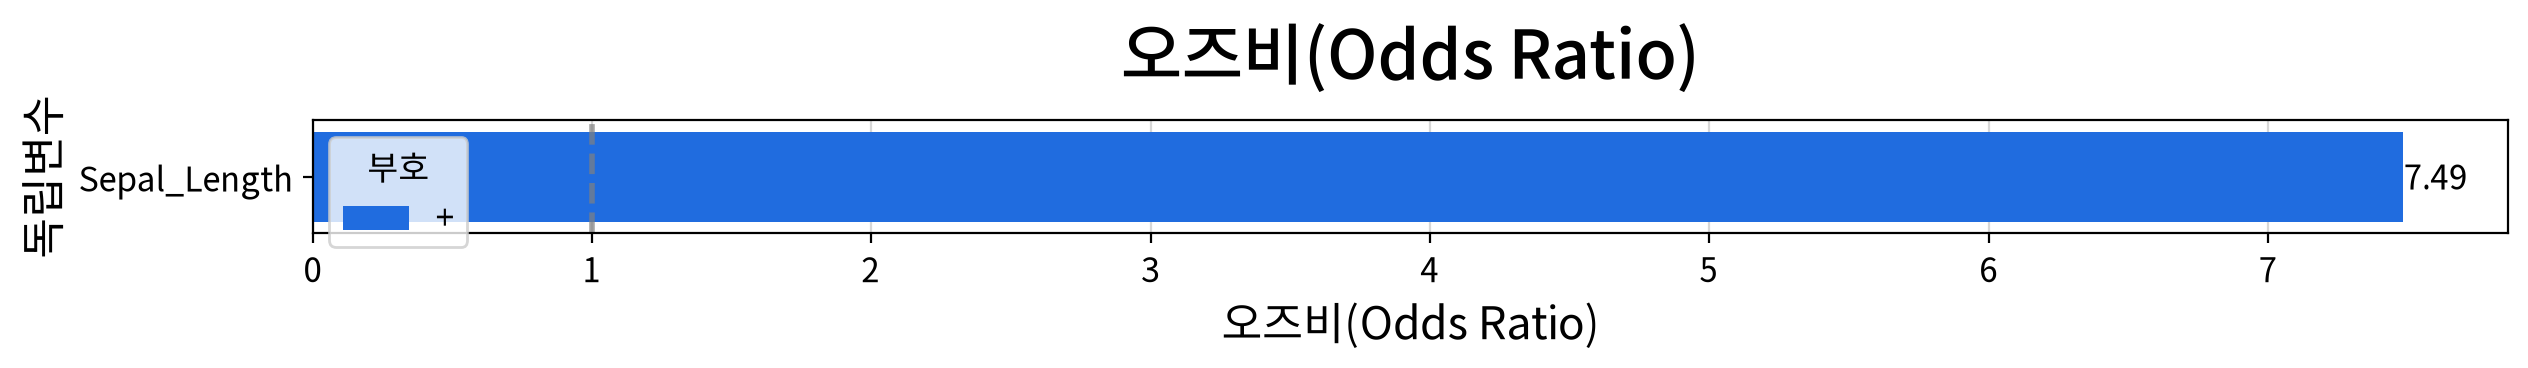

In [16]:
my_logit.plot_odds(fit1, data1, title="오즈비(Odds Ratio)", height=200)

## # 연습문제 

In [ ]:
# 연습문제(pima_indians_diabetes) 순서
# 데이터 불러오기
# 라벨링 필요 여부 판단 → 스킵
# Outcome이 이미 0/1 숫자라서 my_prep.labeling 안 씀
# 분석 대상 컬럼만 추출 (Glucose, Outcome)
# 종속변수 분포 확인 (value_counts/countplot)
# Q1: 0(정상) 500명 — 심한 불균형 아님 확인
# 집단별 독립변수 평균 비교 (groupby/boxplot)
# Q2: 당뇨 집단 평균 혈당 141.3 > 정상 110.0 — "혈당 높을수록 당뇨" 가설 사전 확인
# 모형 적합 (fit_model)
# 모형 적합도 확인 (report_fitness)
# Q3: Pseudo R² = 0.186 — 모형 자체가 쓸 만한지 먼저 판단
# 오즈비 확인 (report_variables)
# Q4: OR = 1.039 (1단위 증가당 오즈 3.9%↑)
# 오즈비 신뢰구간으로 유의성 검증
# Q5: [1.032~1.045], 1 미포함 → 유의함
# 오즈비를 실무 단위로 환산 (exp(B×n))
# Q6: 10단위 증가 시 1.46배 — 1.039×10이 아니라 지수에 10을 곱해야 함
# 로직
# 4→5 (EDA가 6번 모델링보다 먼저): 모델 돌리기 전에 "혈당과 당뇨가 관련 있을 것 같다"는 방향성을 데이터로 먼저 확인 — 나중에 나올 오즈비 부호(양수)가 이 가설과 일치하는지 검산하기 위한 사전 근거
# 7이 8보다 먼저 (모형 적합도 → 오즈비 순): 개별 변수 해석(오즈비)을 보기 전에 모형 자체가 통계적으로 의미 있는지부터 확인해야 함 — 모형이 무의미하면 오즈비를 봐도 소용없음
# 8→9 (오즈비 → 신뢰구간): 오즈비 숫자 하나(1.039)만 보고 끝내면 안 되고, 그 값이 우연이 아닌지 신뢰구간으로 반드시 검증 — 이 순서라서 "오즈비 나왔다고 바로 유의하다고 결론내리면 안 된다"는 걸 학습
# 9→10 (신뢰구간 → 단위 환산): 1단위 효과가 통계적으로 확실하다는 걸 먼저 확정한 다음에야, 그걸 실무 질문(10단위 증가 시엔?)에 적용하는 게 의미 있음. 순서가 바뀌면 유의하지도 않은 값을 확대 해석하는 꼴이 됨

In [ ]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import Markdown, display

In [21]:
origin = load_data('pima_indians_diabetes')
origin.head()

📚 이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [34]:
df = origin[['Glucose', 'Outcome']]
df = my_prep.labeling(df, columns=['Outcome'])
df.head()

Outcome (1종) : 0=0
Outcome (2종) : 0=0, 1=1


,Glucose,Outcome
0,148,1
1,85,0
2,183,1
3,89,0
4,137,1


In [25]:
print(origin['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


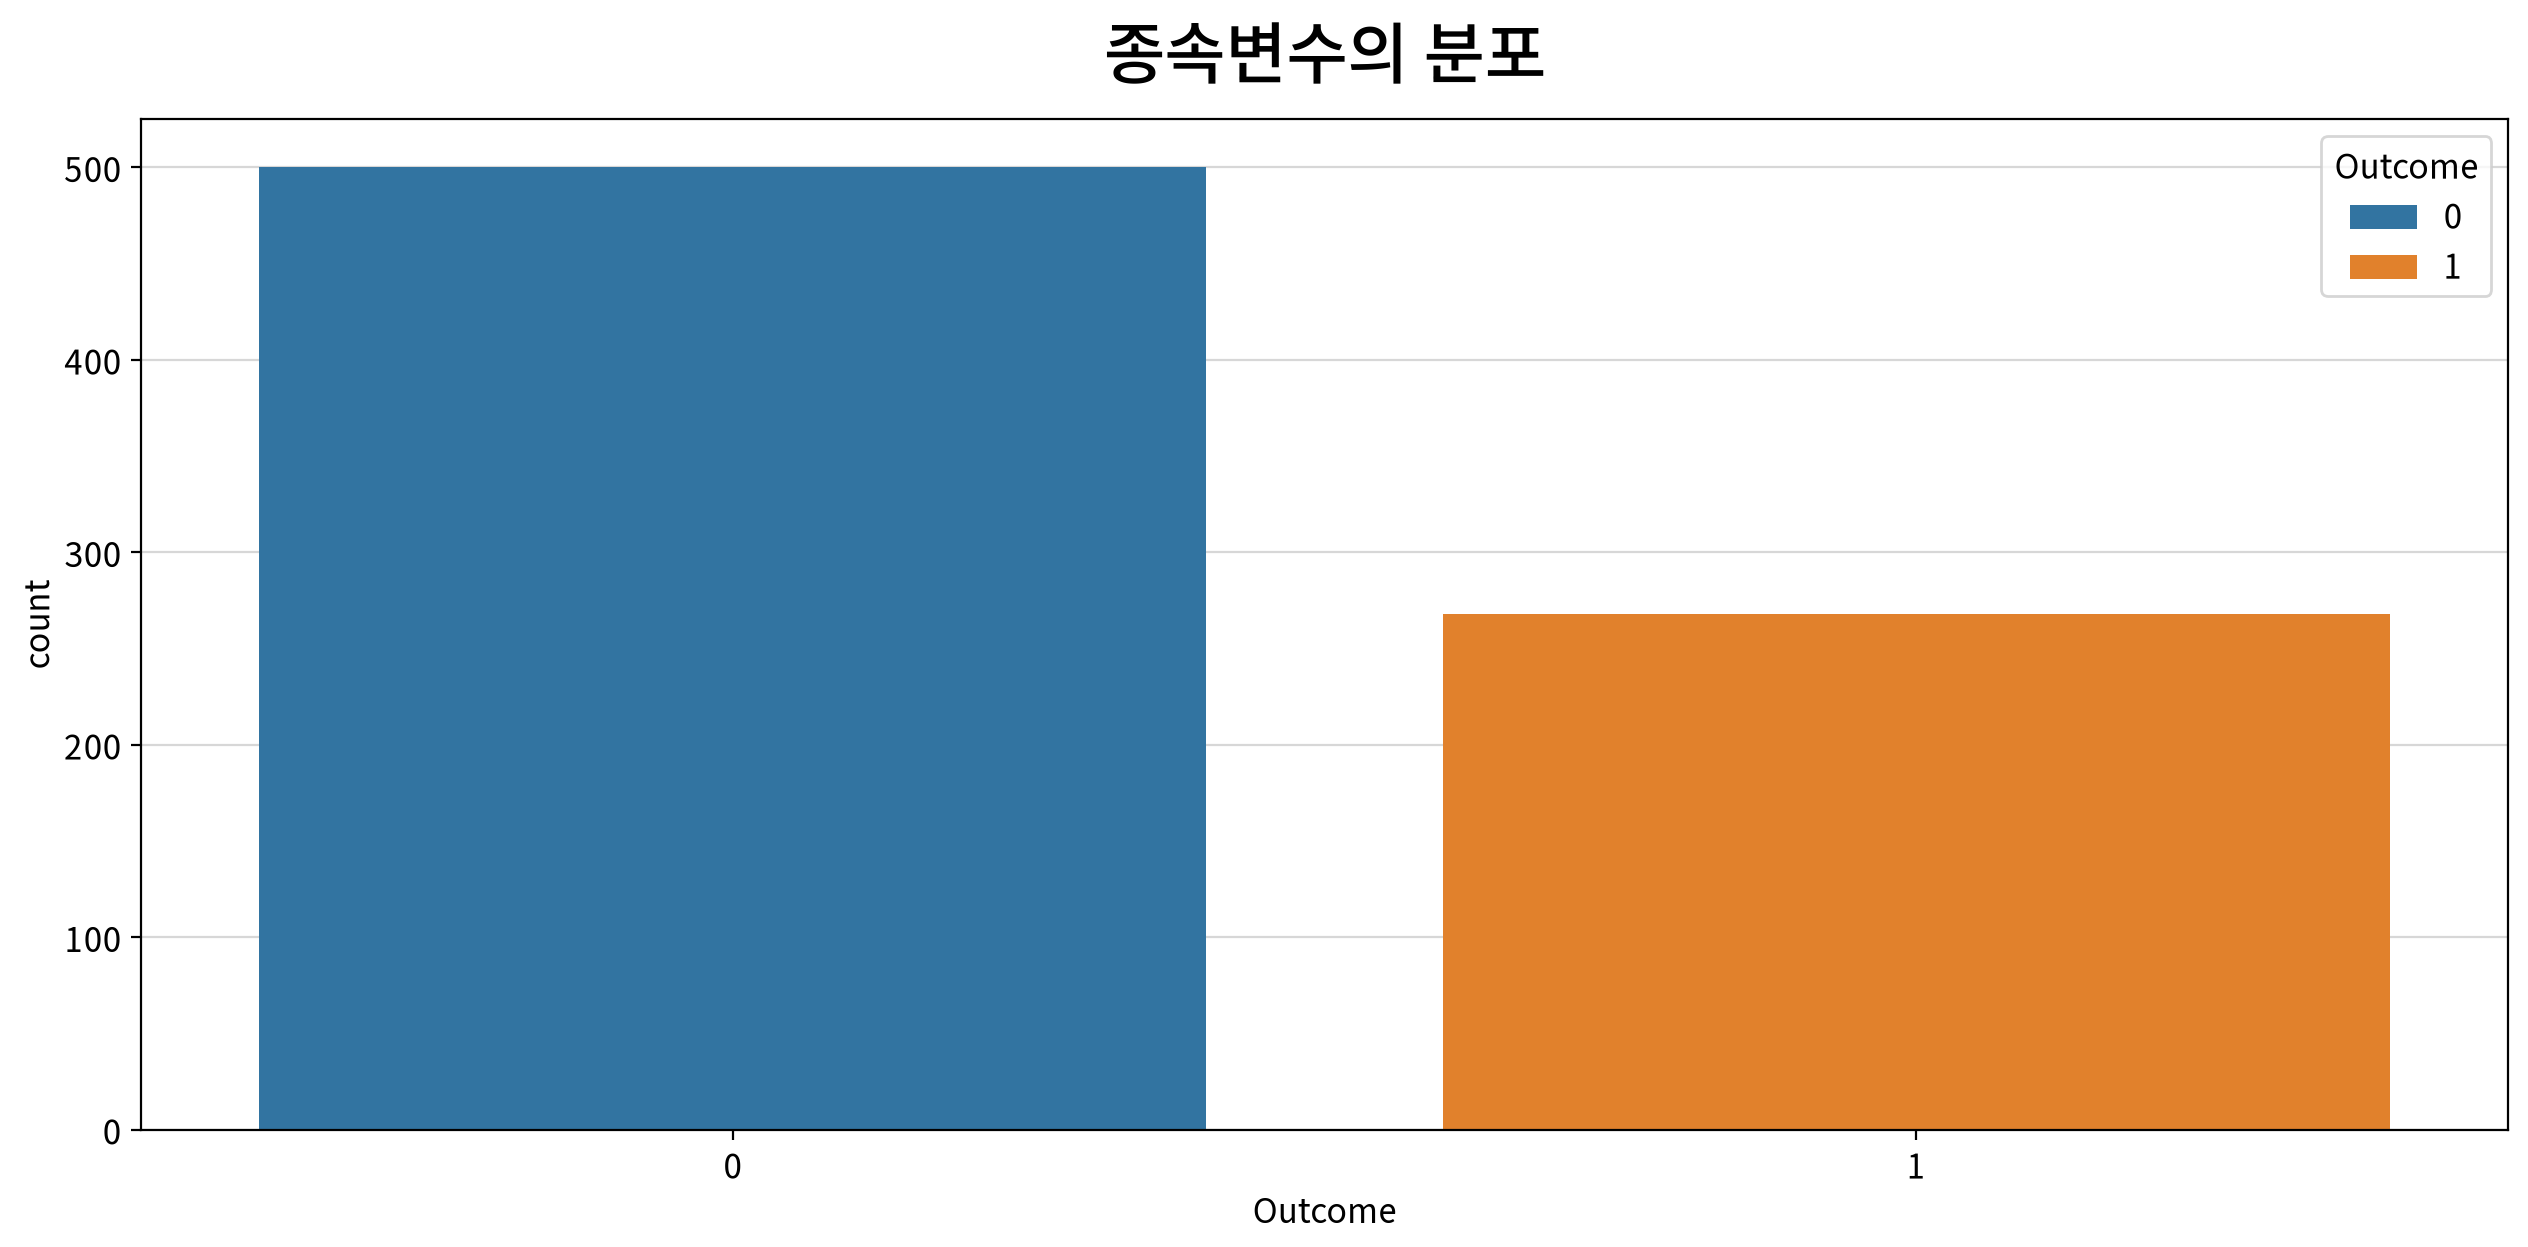

In [26]:
my_plot.countplot(df, x='Outcome', hue='Outcome', 
                  title='종속변수의 분포') 

Outcome
0   109.980
1   141.257
Name: Glucose, dtype: float64


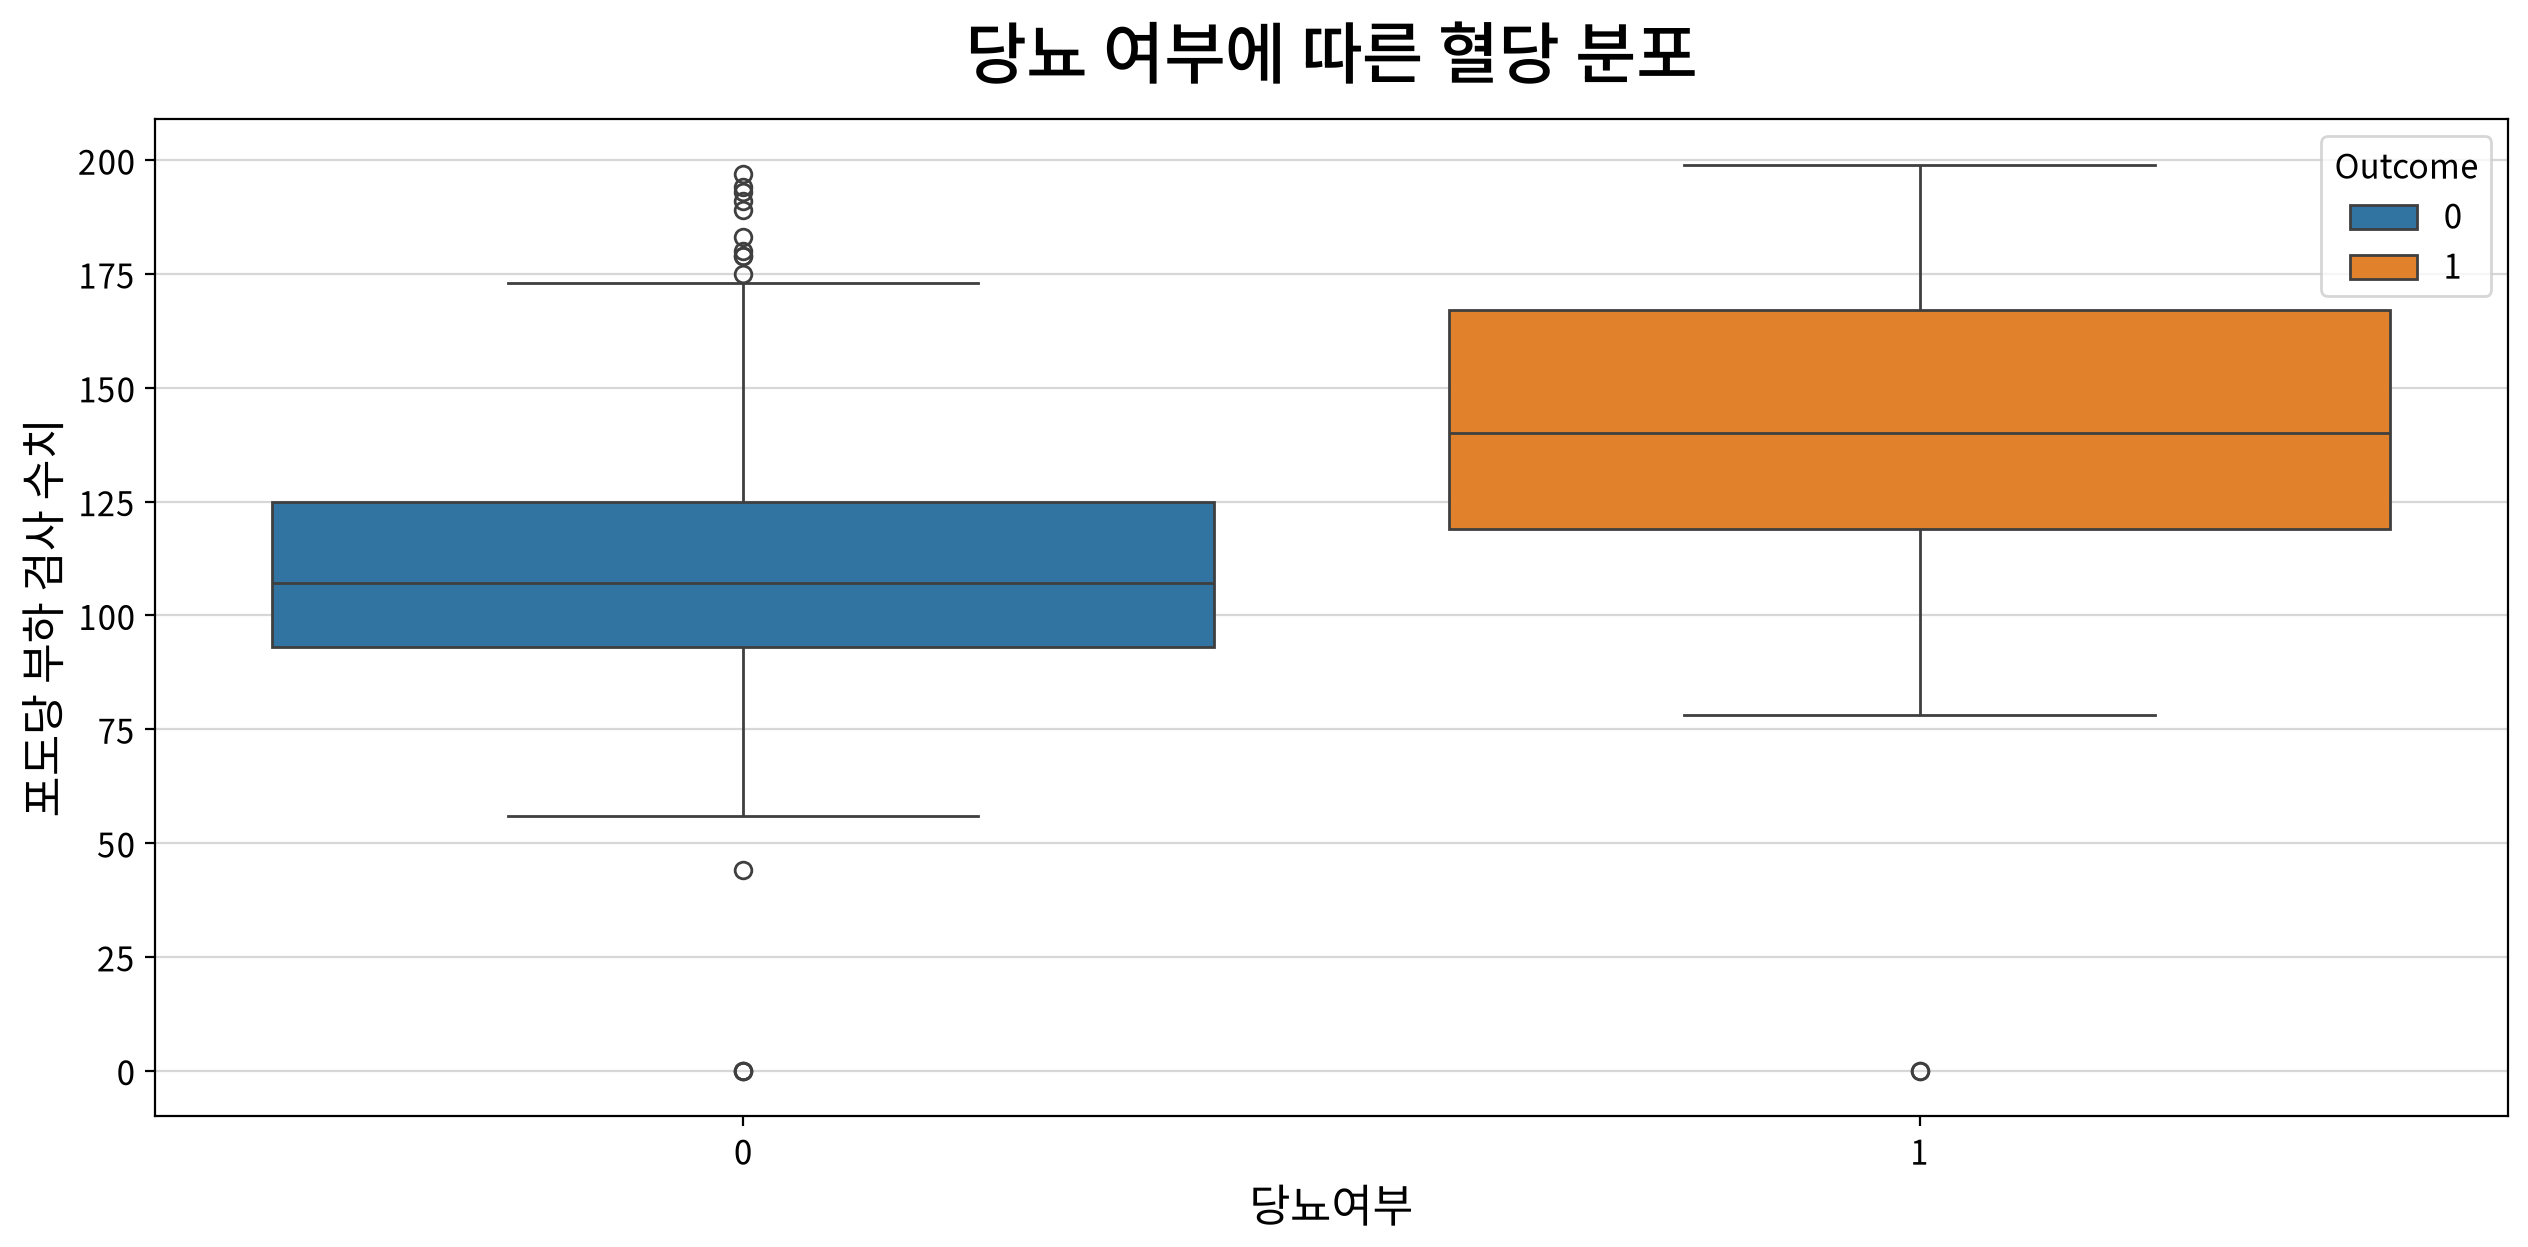

In [35]:
# 
print(df.groupby('Outcome')['Glucose'].mean())

my_plot.boxplot(df, x='Outcome', y='Glucose', hue='Outcome', 
                title='당뇨 여부에 따른 혈당 분포', xlabel='당뇨여부', ylabel='포도당 부하 검사 수치')

In [ ]:
# 문제 2
# 당뇨 판정 집단(1)의 평균 혈당(Glucose)은?
# 141.257

In [ ]:
# 문제 1 
# 종속변수 Outcome의 두 범주(0/1)중 
# 관측치가 더 많은 값과 그 인원수는 ? 
# 0, 500 

In [28]:
data1 = df[['Glucose', 'Outcome']]
fit1 = my_logit.fit_model(data1, y='Outcome', summary=True) 

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.1860
Time:                        17:47:01   Log-Likelihood:                -404.36
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 4.418e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3501      0.421    -12.713      0.000      -6.175      -4.525
Glucose        0.0379      0.003     11.647      0.000       0.031       0.044


In [ ]:
# 문제 3
# 이 모형의 Pseudo R^2 값은 ? 
# 0.1860

In [37]:
display(my_logit.report_variables(fit1, df))

,종속변수,독립변수,B,베타std,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,Glucose,0.038,1.211,0.003,11.647,0.000,1.039,1.032,1.045,1.000,1.000


In [ ]:
# 1.039

In [ ]:
# 1.032 ~ 1.045

In [29]:
display(Markdown(my_logit.report_fitness(fit1)))

**Note. n=768.LL = -404.36, LL-Null = -496.742, LLR x^2 (1) = 184.764, p < 0.001, Pseudo R^2 = 0.186**

Outcome를 종속변수로, Glucose(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR x^2 (1)=184.764, p < 0.001, Pseudo R^2 = 0.186.

즉, 모형의 유사결정계수는 0.186로 양호한적합 수준을 보였다.

> Pseudo R^2는 선형회귀의 R^2처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다

In [30]:
my_logit.report_variables(fit1, data1)

,종속변수,독립변수,B,베타std,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,Glucose,0.038,1.211,0.003,11.647,0.000,1.039,1.032,1.045,1.000,1.000


In [31]:
display(Markdown(my_logit.report_variables_text(fit1, data=data1)))

- **Glucose**의 회귀계수는 **B = 0.0379**, 오즈비는 **OR=1.0386**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다(**z = 11.65**, **p < .001**)즉, **Glucose**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.9% 증가** 하는 것으로 해석된다.

> 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된)범주' 대비 값이다

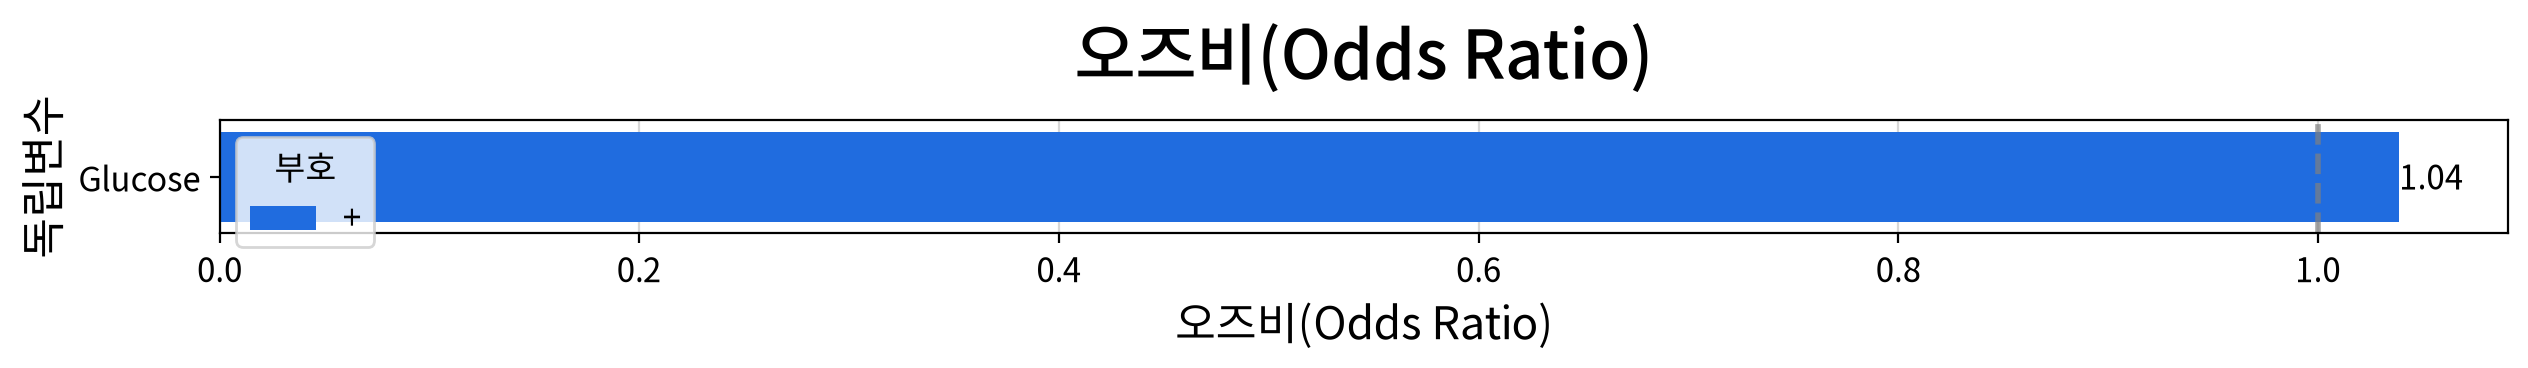

In [32]:
my_logit.plot_odds(fit1, data1, title="오즈비(Odds Ratio)", height=200)

In [39]:
import numpy as np


In [41]:
np.exp(fit1.params['Glucose'] * 10)   # 1.4604


np.float64(1.4604291947344061)

In [42]:
np.exp(fit1.params['Glucose'] * 30)   # 3.1149

np.float64(3.114881421398208)